# PyPSA-Sudan · 2022 reference in pictures
**Selected historical reference · 8,760 hours · national aggregate**

Inspect source capacity, calibrated electricity supply, annual accounting and synthetic hourly dispatch. This one-bus model has no regional capacity allocation; [the regional atlas](01_explore_sudan.ipynb) uses the separately labelled 2024 example.

Saved figures are visible immediately. Choose **Python (pypsa)** and run all cells to refresh them. Annual agreement is calibration, not independent validation.

In [1]:
from pathlib import Path
import json
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display
import pypsa

logging.getLogger("pypsa").setLevel(logging.ERROR)
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "config/reference_2022.json").exists())
FIG = ROOT / "results/notebook_figures"
FIG.mkdir(parents=True, exist_ok=True)
COLORS = {"hydro":"#258eaa", "oil":"#dd9a50", "diesel":"#986445",
          "coal":"#667085", "combustible":"#dd9a50", "other":"#73a65a",
          "import":"#8a70b7", "imports":"#8a70b7", "unserved":"#d75460"}
LABELS = {"hydro":"Hydro", "oil":"Oil", "diesel":"Diesel", "coal":"Coal",
          "combustible":"Combustible fuels", "other":"Other", "import":"Imports",
          "imports":"Imports", "unserved":"Unserved load"}
plt.rcParams.update({"figure.dpi":110, "font.size":10, "axes.spines.top":False,
                     "axes.spines.right":False, "axes.titleweight":"bold",
                     "axes.labelcolor":"#334155", "text.color":"#173347"})

def finish(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=170, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

def donut(ax, values, title, unit):
    values = values[values > 1e-8]
    total = values.sum()
    if total > 0:
        ax.pie(values, colors=[COLORS.get(c, "#8996a4") for c in values.index],
               startangle=90, counterclock=False, wedgeprops={"width":.34,"edgecolor":"white"})
        ax.text(0, 0, f"{total:,.1f}\n{unit}", ha="center", va="center", fontsize=11)
    else:
        ax.pie([1], colors=["#edf1f3"], wedgeprops={"width":.34,"edgecolor":"white"})
        ax.text(0, 0, "No local\ngeneration", ha="center", va="center", fontsize=9, color="#6b7280")
    ax.set_title(title, fontsize=11, pad=8)

In [2]:
n = pypsa.Network(ROOT / "results/reference_2022/network.nc")
stats = pd.read_csv(ROOT / "data/reference/unsd_2022/statistics.csv").set_index("metric")
s = stats.value
energy = n.generators_t.p.mul(n.snapshot_weightings.generators,axis=0).sum()/1e6
assert len(n.snapshots)==8760
display(stats[["value","unit","source_flag"]])

,value,unit,source_flag
metric,,,
gross_generation,16771.0,GWh,not_flagged
gross_combustible,4842.0,GWh,not_flagged
gross_hydro,11804.0,GWh,not_flagged
gross_other,126.0,GWh,not_flagged
plant_own_use,740.0,GWh,not_flagged
net_generation,16031.0,GWh,not_flagged
imports,882.0,GWh,not_flagged
exports,NaN,GWh,not_available_or_not_applicable
losses,3652.0,GWh,not_flagged


## 1 · Installed capacity and annual electricity supply
Left: reported national **net** capacity, including autoproducers. “Other” capacity is a UNSD estimate.
Right: modelled net domestic generation and imports. Net generation by technology is derived through the documented allocation of power-station own use; these technology-level net values are not source observations.

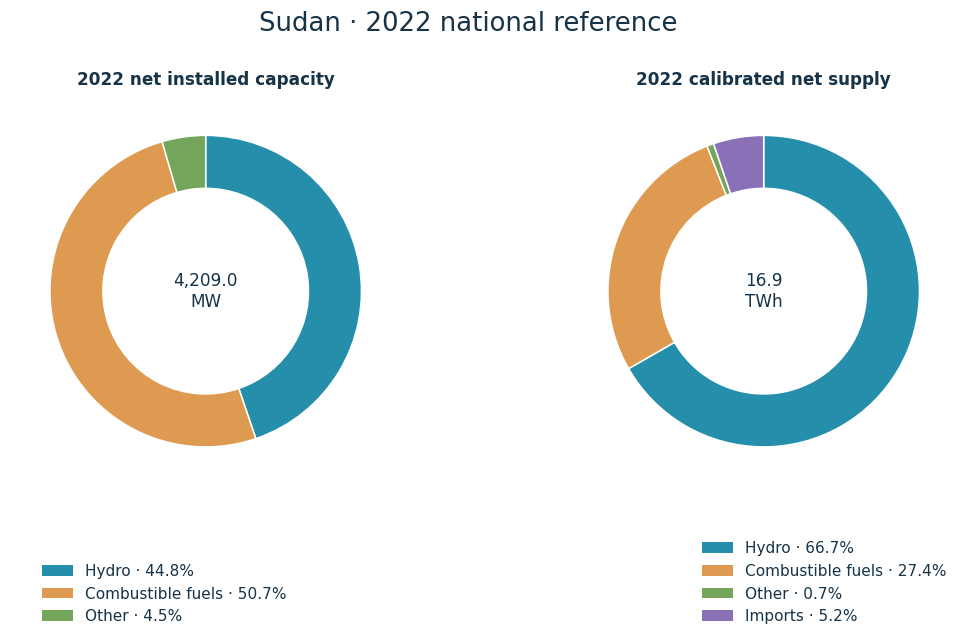

In [3]:
capacity = pd.Series({c:s[f"capacity_{c}"] for c in ["hydro","combustible","other"]})
supply = energy.drop("unserved")
fig, axes = plt.subplots(1,2,figsize=(12,6))
donut(axes[0],capacity,"2022 net installed capacity","MW")
donut(axes[1],supply,"2022 calibrated net supply","TWh")
for x, values in zip([.27,.77],[capacity,supply]):
    fig.legend(handles=[Patch(facecolor=COLORS[c],label=f"{LABELS[c]} · {100*v/values.sum():.1f}%")
                       for c,v in values.items()],loc="lower center",bbox_to_anchor=(x,.03),frameon=False)
fig.suptitle("Sudan · 2022 national reference", fontsize=17)
fig.subplots_adjust(bottom=.26,top=.85)
finish(fig,"reference_2022_national_donuts")

## 2 · Follow the electricity balance
Gross generation minus station own use gives net generation. Net generation plus imports balances supplied consumption plus system losses. Consumption is estimated; losses include nontechnical losses. Missing exports are assumed zero to close this published balance.

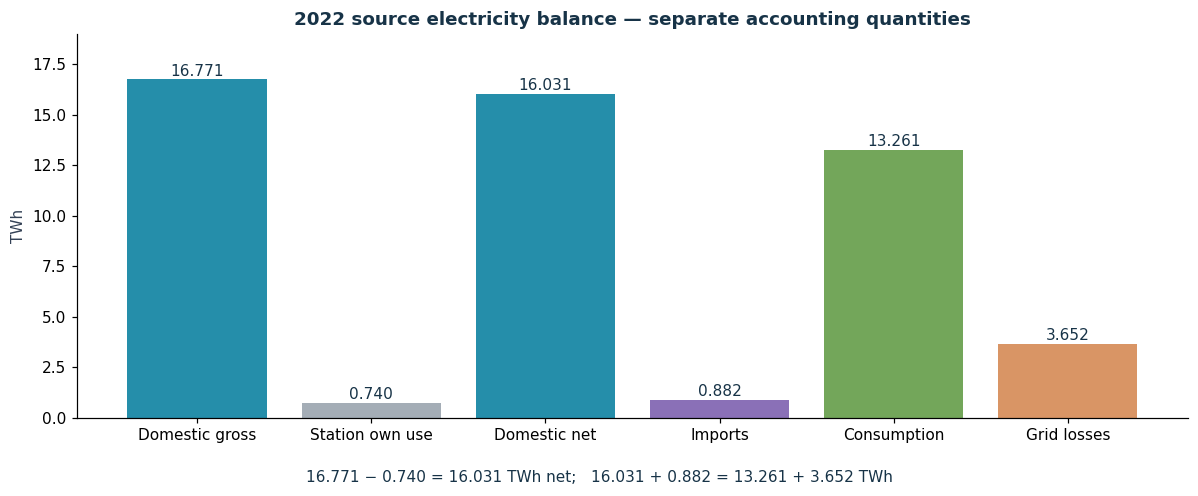

In [4]:
fig, ax = plt.subplots(figsize=(11,4.5))
labels = ["Domestic gross","Station own use","Domestic net","Imports","Consumption","Grid losses"]
values = [s.gross_generation,s.plant_own_use,s.net_generation,s.imports,s.consumption,s.losses]
ax.bar(labels,np.array(values)/1000,color=["#258eaa","#a4adb6","#258eaa","#8a70b7","#73a65a","#d99565"])
for i,v in enumerate(values):
    ax.text(i,v/1000+.18,f"{v/1000:.3f}",ha="center",fontsize=10)
ax.set(ylabel="TWh",ylim=(0,19),title="2022 source electricity balance — separate accounting quantities")
fig.text(.5,.015,"16.771 − 0.740 = 16.031 TWh net;   16.031 + 0.882 = 13.261 + 3.652 TWh",ha="center",fontsize=10)
fig.tight_layout(rect=(0,.06,1,1))
finish(fig,"reference_2022_energy_balance")

## 3 · Inspect a week from the annual dispatch
Edit `WEEK_START` to another 2022 date. This is a window into the solved year, not a new weekly optimization. The hourly load shape and timing are synthetic. With only an annual hydro budget, hydro timing is underdetermined; apparent seasonality must not be interpreted as measured hydrology.

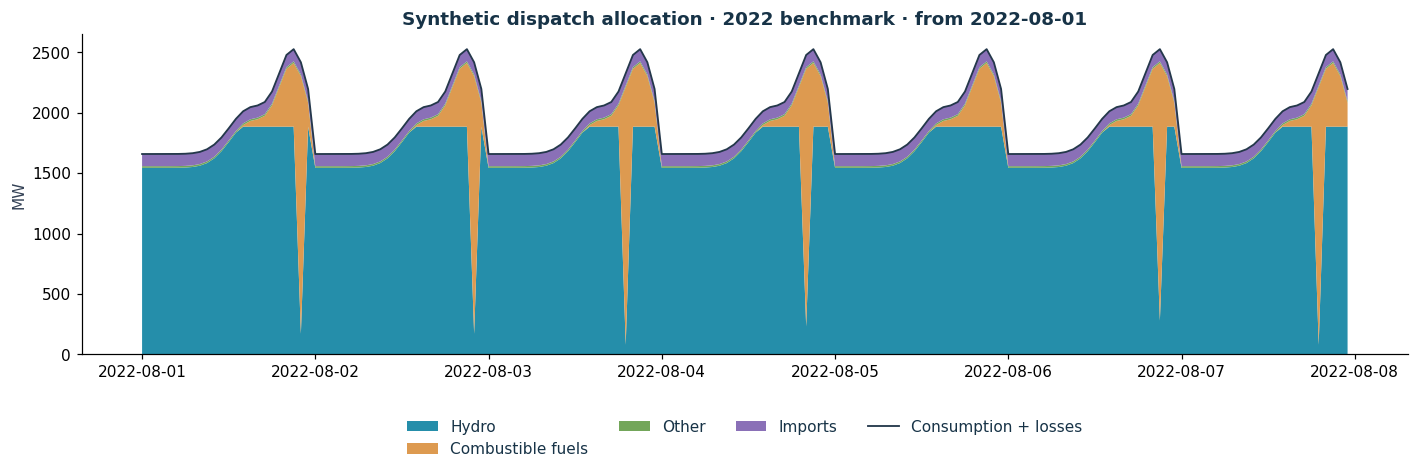

In [5]:
WEEK_START = "2022-08-01"
start = pd.Timestamp(WEEK_START)
window = n.generators_t.p.loc[start:start+pd.Timedelta(hours=167)]
assert len(window)>0,"Choose a date in 2022"
active = window.columns[window.max()>1e-6]
fig,ax = plt.subplots(figsize=(13,4.5))
ax.stackplot(window.index,*[window[c] for c in active],colors=[COLORS[c] for c in active],labels=[LABELS[c] for c in active])
ax.plot(window.index,n.loads_t.p_set.loc[window.index].sum(axis=1),color="#24384b",lw=1.2,label="Consumption + losses")
ax.set(ylabel="MW",title=f"Synthetic dispatch allocation · 2022 benchmark · from {WEEK_START}")
ax.legend(loc="upper center",bbox_to_anchor=(.5,-.16),ncol=4,frameon=False)
fig.tight_layout()
finish(fig,"reference_2022_dispatch_window")

## 4 · Calibration check and what is still missing
Matching the annual targets is an accounting check. The model assumes unrestricted internal transfers and full installed availability; zero model shortage does not establish historical reliability.

In [6]:
comparison = pd.read_csv(ROOT / "results/reference_2022/calibration_comparison.csv",index_col=0)
display(comparison.round(3))
display(pd.DataFrame({"Needed for regional 2022 visuals":[
    "Dated unit ledger and net/gross capacity reconciliation",
    "Substations, transmission connections and line/transformer ratings",
    "Regional monthly/hourly supplied demand and loss allocation",
    "Monthly hydro output/inflows, outages and import flows"]}))

,derived_net_target_mwh,model_mwh,difference_mwh
hydro,1.128249e+07,1.128249e+07,-0.0
combustible,4.628077e+06,4.628077e+06,0.0
other,1.204332e+05,1.204332e+05,-0.0


,Needed for regional 2022 visuals
0,Dated unit ledger and net/gross capacity recon...
1,"Substations, transmission connections and line..."
2,Regional monthly/hourly supplied demand and lo...
3,"Monthly hydro output/inflows, outages and impo..."


Sources: [UNSD Sudan table, p.196](https://unstats.un.org/unsd/energystats/pubs/eprofiles/2023/prt.pdf#page=30), [source flags](https://unstats.un.org/unsd/energystats/pubs/eprofiles/2023/04.pdf), and [project accounting method](../docs/REFERENCE_YEAR_2022.md).

PNG exports: `results/notebook_figures/`. The companion HTML files are read-only previews; the `.ipynb` files contain editable Python cells.